# Potato Blight Detection — MobileNetV2 Transfer Learning

In [4]:
# %pip install tensorflow

import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR   = './PlantVillage'
CLASSES    = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
IMG_SIZE   = 224
BATCH      = 32
EPOCHS_FT  = 10   # fine-tune epochs
EPOCHS_TL  = 5    # transfer-learning (frozen base) epochs
SEED       = 42

## 1. Load & Split Data

In [5]:
# Build a filtered dataset containing only the 3 potato classes
import shutil, pathlib

POTATO_DIR = './potato_data'
if not os.path.exists(POTATO_DIR):
    for cls in CLASSES:
        src = os.path.join(DATA_DIR, cls)
        dst = os.path.join(POTATO_DIR, cls)
        shutil.copytree(src, dst)
    print('Potato subset created.')
else:
    print('Potato subset already exists.')

for cls in CLASSES:
    n = len(os.listdir(os.path.join(POTATO_DIR, cls)))
    print(f'{cls}: {n} images')

Potato subset created.
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images
Potato___healthy: 152 images


In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    POTATO_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    POTATO_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode='categorical'
)

CLASS_NAMES = train_ds.class_names
print('Classes:', CLASS_NAMES)

Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [7]:
# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

## 2. Augmentation + Preprocessing

In [8]:
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name='augmentation')

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input  # scales to [-1, 1]

## 3. Build Model (MobileNetV2 Transfer Learning)

In [9]:
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze for initial training

inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = augment(inputs)
x       = preprocess(x)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Phase 1 — Train Classification Head

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb = [
    callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
]

history1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_TL, callbacks=cb)

Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7172 - loss: 0.7571 - val_accuracy: 0.8814 - val_loss: 0.3706
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9065 - loss: 0.2585 - val_accuracy: 0.9628 - val_loss: 0.1699
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9454 - loss: 0.1697 - val_accuracy: 0.9674 - val_loss: 0.1287
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9535 - loss: 0.1396 - val_accuracy: 0.9674 - val_loss: 0.1060
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9663 - loss: 0.1161 - val_accuracy: 0.9930 - val_loss: 0.0868


## 5. Phase 2 — Fine-Tune Top Layers of Base Model

In [11]:
base_model.trainable = True
# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT, callbacks=cb)
print('Fine-tuning complete.')

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9332 - loss: 0.1958 - val_accuracy: 0.9837 - val_loss: 0.0801
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9541 - loss: 0.1301 - val_accuracy: 0.9814 - val_loss: 0.0735
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9524 - loss: 0.1217 - val_accuracy: 0.9791 - val_loss: 0.0662
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9675 - loss: 0.0956 - val_accuracy: 0.9791 - val_loss: 0.0610
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9710 - loss: 0.0827 - val_accuracy: 0.9767 - val_loss: 0.0627
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9710 - loss: 0.0823 - val_accuracy: 0.9791 - val_loss: 0.0604
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9791 - loss: 0.0705 - val_accuracy: 0.9814 - val_loss: 0.0570
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9750 - loss: 0.0697 - val_accuracy: 0.9791 - val_loss:

## 6. Evaluation

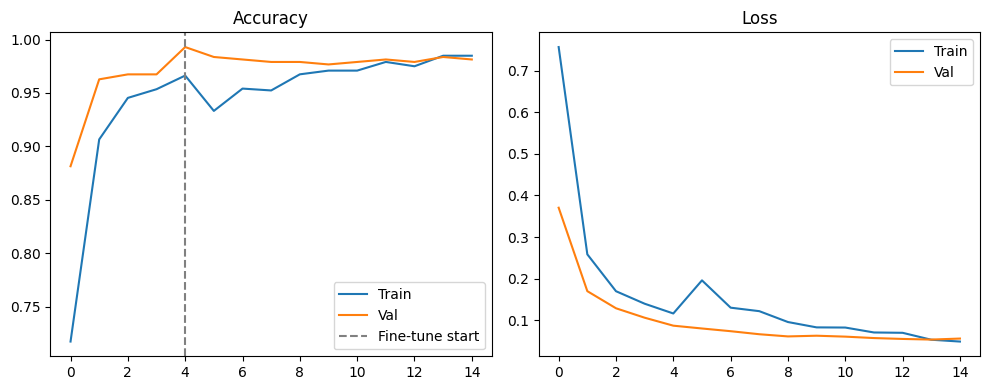

In [12]:
# Plot training curves
def plot_history(h1, h2):
    acc  = h1.history['accuracy']  + h2.history['accuracy']
    vacc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(acc, label='Train'); plt.plot(vacc, label='Val')
    plt.axvline(len(h1.history['accuracy'])-1, color='gray', linestyle='--', label='Fine-tune start')
    plt.title('Accuracy'); plt.legend()

    loss  = h1.history['loss']  + h2.history['loss']
    vloss = h1.history['val_loss'] + h2.history['val_loss']
    plt.subplot(1,2,2)
    plt.plot(loss, label='Train'); plt.plot(vloss, label='Val')
    plt.title('Loss'); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(history1, history2)

                       precision    recall  f1-score   support

Potato___Early_blight       1.00      0.98      0.99       182
 Potato___Late_blight       0.99      0.99      0.99       208
     Potato___healthy       0.91      1.00      0.95        40

             accuracy                           0.98       430
            macro avg       0.96      0.99      0.98       430
         weighted avg       0.98      0.98      0.98       430



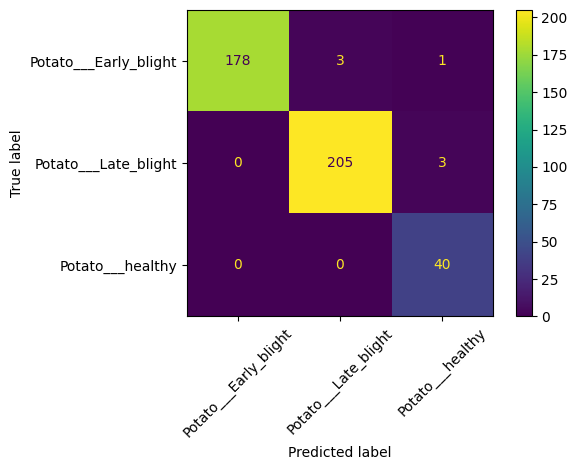

In [13]:
# Classification report & confusion matrix
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(xticks_rotation=45)
plt.tight_layout(); plt.show()

## 7. Grad-CAM Explainability

In [ ]:
import cv2

def get_gradcam_heatmap(model, base_model, img_array, last_conv_layer='Conv_1'):
    """
    Grad-CAM using base_model directly.
    Conv_1 lives inside base_model, not the outer model,
    so we build a sub-model from base_model's input to Conv_1 output + base_model output,
    then chain the outer model's head manually.
    """
    # Sub-model: base_model input -> (Conv_1 feature maps, base_model output)
    base_grad_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer).output, base_model.output]
    )

    # Preprocess the image the same way the outer model does (no augmentation at inference)
    preprocessed = preprocess(img_array)

    with tf.GradientTape() as tape:
        conv_outputs, base_out = base_grad_model(preprocessed)
        tape.watch(conv_outputs)
        # Run the head layers manually (GAP -> Dropout -> Dense)
        x = model.get_layer('global_average_pooling2d')(base_out)
        x = model.get_layer('dropout')(x, training=False)
        predictions = model.get_layer('dense')(x)
        top_class = tf.argmax(predictions[0])
        loss = predictions[:, top_class]

    grads   = tape.gradient(loss, conv_outputs)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0) / (heatmap.max() + 1e-8)
    return heatmap, int(top_class), float(tf.reduce_max(predictions).numpy())


def overlay_gradcam(img_path, model, base_model, class_names):
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_input = np.expand_dims(img_array, 0)

    heatmap, pred_idx, confidence = get_gradcam_heatmap(model, base_model, img_input)

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = heatmap_colored * 0.4 + img_array
    superimposed = np.clip(superimposed / superimposed.max() * 255, 0, 255).astype('uint8')

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(img_array.astype('uint8')); plt.title('Original'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(superimposed); plt.axis('off')
    plt.title(f'Grad-CAM: {class_names[pred_idx]} ({confidence:.1%})')
    plt.tight_layout(); plt.show()


# Test on a sample validation image
sample_path = next(pathlib.Path(POTATO_DIR).rglob('*.jpg'))
overlay_gradcam(str(sample_path), model, base_model, CLASS_NAMES)

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 3.7 MB/s eta 0:00:11
    --------------------------------------- 0.8/40.2 MB 3.7 MB/s eta 0:00:11
   - -------------------------------------- 1.3/40.2 MB 2.0 MB/s eta 0:00:20
   - -------------------------------------- 1.6/40.2 MB 1.8 MB/s eta 0:00:22
   -- ------------------------------------- 2.1/40.2 MB 1.8 MB/s eta 0:00:22
   -- ------------------------------------- 2.6/40.2 MB 1.9 MB/s eta 0:00:21
   --- ------------------------------------ 3.1/40.2 MB 2.0 MB/s eta 0:00:19
   --- ------------------------------------ 3.4/40.2 MB 2.0 MB/s eta 0:00:19
   --- ------------------------------------ 3.9/40.2 MB 1.9 MB/s eta 0:00:20
   ---- ----------------------------------- 4.2/40.2 MB 1.9 MB/s eta 0:00:20
   ---- ------------

  You can safely remove it manually.
  You can safely remove it manually.


ValueError: No such layer: Conv_1. Existing layers are: ['input_layer_1', 'augmentation', 'mobilenetv2_1.00_224', 'global_average_pooling2d', 'dropout', 'dense'].

## 8. Save Model & Class Names

In [ ]:
model.save('potato_blight_model.keras')
np.save('class_names.npy', CLASS_NAMES)
print('Model and class names saved.')